# H19 — Cross-cohort meta-analysis (rs3184504)

**Goal:** combine per-donor follicle metrics across the two independent spleen cohorts to test rs3184504 effects with greater statistical power than either alone.

**Cohorts (independent at the donor level except for 4 overlapping HDL IDs):**
| Cohort | Source table | n donors | Stain |
|---|---|---|---|
| Fluorescent | `H10_feature_matrix.csv` | 13 | Phenocycler / CODEX (multiplex IF) |
| H&E | `HE_per_donor.csv` | 27 | Hematoxylin & eosin (morphology only) |

**Overlapping metrics (4):** Follicle Count, Mean Follicle Area (µm²), Follicle Density (n/mm²), Follicle Area Fraction.

**Analysis plan:**
1. Per-cohort stats (Kruskal-Wallis, pairwise Mann-Whitney with rank-biserial r, Spearman dosage).
2. Sign / direction concordance between cohorts.
3. Stouffer-combined p-values for the dosage trend (sqrt(n) weighting).
4. Random-effects meta-analysis on rank-biserial effect sizes (DerSimonian-Laird) with I² heterogeneity.
5. Sample-level consistency on the 4 overlapping donors.
6. Forest plots per metric.

This notebook does **not** pool the raw measurements — definitions of "tissue area" differ between H&E (one whole-section polygon) and fluorescent (sum of region annotations). Meta-analysis is over per-cohort effect sizes, which is robust to that definitional difference.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, norm, spearmanr

# data_utils on path
PROJECT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(PROJECT / "analysis"))
import data_utils as du

du.setup_style()
GENO_ORDER = du.GENO_ORDER
PALETTE = du.GENO_PALETTE
COHORT_PALETTE = {"Fluorescent": "#3366CC", "H&E": "#CC6633", "Pooled": "#222222"}

print("Project root:", PROJECT)

Project root: /home/smith6jt/SpleenFollicleCounterQP


## 1. Load both cohorts

In [2]:
he = pd.read_csv(PROJECT / "analysis" / "tables" / "HE_per_donor.csv")
flu = pd.read_csv(PROJECT / "analysis" / "tables" / "H10_feature_matrix.csv")

# Harmonize column names → unified schema
HE_RENAME = {
    "Follicle_Count":           "Follicle_Count",
    "Follicle_Area_Mean_um2":   "Follicle_Mean_Area",
    "Follicle_Density_per_mm2": "Follicle_Density",
    "Follicle_Fraction":        "Follicle_Fraction",
}
FLU_RENAME = {
    "Follicle_count":     "Follicle_Count",
    "Follicle_mean_area": "Follicle_Mean_Area",
    "Follicle_density":   "Follicle_Density",
    "Follicle_fraction":  "Follicle_Fraction",
}

he_unified = he[["Sample", "Genotype"] + list(HE_RENAME)].rename(columns=HE_RENAME).copy()
he_unified["Cohort"] = "H&E"

flu_unified = flu[["Sample", "Genotype"] + list(FLU_RENAME)].rename(columns=FLU_RENAME).copy()
flu_unified["Cohort"] = "Fluorescent"

combined = pd.concat([flu_unified, he_unified], ignore_index=True)
combined["Genotype"] = pd.Categorical(combined["Genotype"], categories=GENO_ORDER, ordered=True)

print("Combined cohort counts:")
print(combined.groupby(["Cohort", "Genotype"], observed=True).size().unstack(fill_value=0))
print()
overlap = sorted(set(he_unified["Sample"]) & set(flu_unified["Sample"]))
print(f"Donors in both cohorts (n={len(overlap)}):", overlap)
combined.head()

Combined cohort counts:
Genotype     C/C  C/T  T/T
Cohort                    
Fluorescent    4    6    3
H&E            9    9    9

Donors in both cohorts (n=4): ['HDL055', 'HDL063', 'HDL073', 'HDL086']


,Sample,Genotype,Follicle_Count,Follicle_Mean_Area,Follicle_Density,Follicle_Fraction,Cohort
0,1901HBMP004,T/T,54.0,41818.240370,354.709648,0.180979,Fluorescent
1,HBMP006,C/T,7.0,160696.671429,458.716942,0.056733,Fluorescent
2,HBMP007,C/T,8.0,51882.587500,322.844345,0.023009,Fluorescent
3,HDL011,C/C,128.0,33903.315625,226.978169,0.038910,Fluorescent
4,HDL043,C/T,176.0,104105.552273,65.383815,0.118608,Fluorescent


## 2. Per-cohort statistics

For each metric × cohort, run Kruskal-Wallis, all 3 pairwise Mann-Whitney tests with rank-biserial r, and a Spearman dosage trend (genotype 0/1/2). Same framework as H1–H18.

In [3]:
METRICS = ["Follicle_Count", "Follicle_Mean_Area", "Follicle_Density", "Follicle_Fraction"]

per_cohort_rows = []
for cohort, sub in combined.groupby("Cohort"):
    for metric in METRICS:
        stats = du.full_stats_table(sub, metric, label=metric)
        stats.insert(0, "Cohort", cohort)
        stats.insert(1, "n", sub[metric].notna().sum())
        per_cohort_rows.append(stats)

per_cohort_stats = pd.concat(per_cohort_rows, ignore_index=True)
du.save_table(per_cohort_stats, "H19_per_cohort_stats")
per_cohort_stats

Saved: analysis/tables/H19_per_cohort_stats.csv


,Cohort,n,Test,Metric,Statistic,p,Effect_Size
0,Fluorescent,13,Kruskal-Wallis,Follicle_Count,1.703297,0.426711,
1,Fluorescent,13,Mann-Whitney (C/C vs C/T),Follicle_Count,16.000000,0.476190,r=-0.333
2,Fluorescent,13,Mann-Whitney (C/C vs T/T),Follicle_Count,6.000000,1.000000,r=0.000
3,Fluorescent,13,Mann-Whitney (C/T vs T/T),Follicle_Count,4.000000,0.261905,r=0.556
4,Fluorescent,13,Spearman dosage,Follicle_Count,0.014766,0.961814,rho=0.015
5,Fluorescent,13,Kruskal-Wallis,Follicle_Mean_Area,3.461538,0.177148,
6,Fluorescent,13,Mann-Whitney (C/C vs C/T),Follicle_Mean_Area,4.000000,0.114286,r=0.667
7,Fluorescent,13,Mann-Whitney (C/C vs T/T),Follicle_Mean_Area,6.000000,1.000000,r=0.000
8,Fluorescent,13,Mann-Whitney (C/T vs T/T),Follicle_Mean_Area,14.000000,0.261905,r=-0.556
9,Fluorescent,13,Spearman dosage,Follicle_Mean_Area,0.103362,0.736849,rho=0.103


## 3. Effect-size extraction

Pull rank-biserial r (per pairwise comparison) and Spearman ρ (dosage trend) into a tidy table for plotting / pooling.

In [4]:
def cohort_effects(data, cohort_label):
    rows = []
    for metric in METRICS:
        d = data.dropna(subset=[metric, "Genotype"])
        # Pairwise rank-biserial
        for g1, g2 in [("C/C", "C/T"), ("C/C", "T/T"), ("C/T", "T/T")]:
            x = d[d["Genotype"] == g1][metric].values
            y = d[d["Genotype"] == g2][metric].values
            if len(x) and len(y):
                u, p = mannwhitneyu(x, y, alternative="two-sided")
                r = 1 - 2 * u / (len(x) * len(y))
            else:
                r, p = np.nan, np.nan
            rows.append({"Cohort": cohort_label, "Metric": metric,
                         "Test": f"MW {g1} vs {g2}", "Effect": r, "p": p,
                         "n1": len(x), "n2": len(y), "n": len(x) + len(y)})
        # Spearman dosage
        ordinal = d["Genotype"].astype(str).map({"C/C": 0, "C/T": 1, "T/T": 2})
        if ordinal.notna().sum() >= 3:
            rho, p = spearmanr(ordinal, d[metric])
        else:
            rho, p = np.nan, np.nan
        rows.append({"Cohort": cohort_label, "Metric": metric,
                     "Test": "Spearman dosage", "Effect": rho, "p": p,
                     "n1": np.nan, "n2": np.nan, "n": ordinal.notna().sum()})
    return pd.DataFrame(rows)

flu_eff = cohort_effects(flu_unified, "Fluorescent")
he_eff  = cohort_effects(he_unified,  "H&E")
effects = pd.concat([flu_eff, he_eff], ignore_index=True)
du.save_table(effects, "H19_effect_sizes")
effects

Saved: analysis/tables/H19_effect_sizes.csv


,Cohort,Metric,Test,Effect,p,n1,n2,n
0,Fluorescent,Follicle_Count,MW C/C vs C/T,-0.333333,0.476190,4.0,6.0,10
1,Fluorescent,Follicle_Count,MW C/C vs T/T,0.000000,1.000000,4.0,3.0,7
2,Fluorescent,Follicle_Count,MW C/T vs T/T,0.555556,0.261905,6.0,3.0,9
3,Fluorescent,Follicle_Count,Spearman dosage,0.014766,0.961814,NaN,NaN,13
4,Fluorescent,Follicle_Mean_Area,MW C/C vs C/T,0.666667,0.114286,4.0,6.0,10
5,Fluorescent,Follicle_Mean_Area,MW C/C vs T/T,0.000000,1.000000,4.0,3.0,7
6,Fluorescent,Follicle_Mean_Area,MW C/T vs T/T,-0.555556,0.261905,6.0,3.0,9
7,Fluorescent,Follicle_Mean_Area,Spearman dosage,0.103362,0.736849,NaN,NaN,13
8,Fluorescent,Follicle_Density,MW C/C vs C/T,-0.083333,0.914286,4.0,6.0,10
9,Fluorescent,Follicle_Density,MW C/C vs T/T,0.333333,0.628571,4.0,3.0,7


## 4. Direction concordance

For each (Metric, Test) row, compare effect-size sign between the two cohorts. Sign agreement is informal evidence the cohorts are seeing the same direction even when neither is significant alone.

In [5]:
wide = effects.pivot_table(index=["Metric", "Test"], columns="Cohort", values="Effect").reset_index()
wide["Sign_agree"] = np.sign(wide["Fluorescent"]) == np.sign(wide["H&E"])
wide["Both_p_lt_0.1"] = (
    effects.pivot_table(index=["Metric", "Test"], columns="Cohort", values="p")
           .reset_index()[["Fluorescent", "H&E"]] < 0.1
).all(axis=1)
agree_rate = wide["Sign_agree"].mean()
print(f"Sign-agreement rate across {len(wide)} (metric, test) pairs: {agree_rate:.0%}")
du.save_table(wide, "H19_concordance")
wide

Sign-agreement rate across 16 (metric, test) pairs: 31%
Saved: analysis/tables/H19_concordance.csv


Cohort,Metric,Test,Fluorescent,H&E,Sign_agree,Both_p_lt_0.1
0,Follicle_Count,MW C/C vs C/T,-0.333333,0.407407,False,False
1,Follicle_Count,MW C/C vs T/T,0.000000,0.209877,False,False
2,Follicle_Count,MW C/T vs T/T,0.555556,-0.407407,False,False
3,Follicle_Count,Spearman dosage,0.014766,0.099020,True,False
4,Follicle_Density,MW C/C vs C/T,-0.083333,0.234568,False,False
5,Follicle_Density,MW C/C vs T/T,0.333333,0.012346,True,False
6,Follicle_Density,MW C/T vs T/T,0.333333,-0.259259,False,False
7,Follicle_Density,Spearman dosage,0.162426,0.000000,False,False
8,Follicle_Fraction,MW C/C vs C/T,0.083333,0.283951,True,False
9,Follicle_Fraction,MW C/C vs T/T,0.500000,-0.135802,False,False


Saved: analysis/figures/H19_concordance_scatter.png


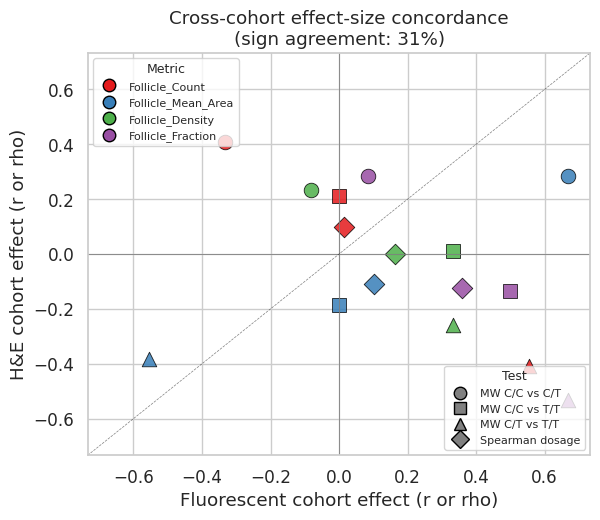

In [6]:
# Concordance scatter: cohort A effect vs cohort B effect, one point per (metric, test)
fig, ax = plt.subplots(figsize=(6.2, 5.4))
mask = wide[["Fluorescent", "H&E"]].notna().all(axis=1)
sub = wide[mask]
markers = {"MW C/C vs C/T": "o", "MW C/C vs T/T": "s", "MW C/T vs T/T": "^",
           "Spearman dosage": "D"}
metric_color = dict(zip(METRICS, sns.color_palette("Set1", 4)))
for _, row in sub.iterrows():
    ax.scatter(row["Fluorescent"], row["H&E"],
               s=110, alpha=0.85,
               marker=markers.get(row["Test"], "o"),
               color=metric_color[row["Metric"]],
               edgecolor="black", linewidth=0.6)
ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
lim = max(abs(sub[["Fluorescent", "H&E"]].values).max(), 0.6) * 1.1
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.plot([-lim, lim], [-lim, lim], color="black", lw=0.5, ls="--", alpha=0.5)
ax.set_xlabel("Fluorescent cohort effect (r or rho)")
ax.set_ylabel("H&E cohort effect (r or rho)")
ax.set_title(f"Cross-cohort effect-size concordance\n(sign agreement: {agree_rate:.0%})")

# Two legends
metric_handles = [plt.Line2D([0], [0], marker="o", linestyle="None", markersize=9,
                              markerfacecolor=c, markeredgecolor="black", label=m)
                  for m, c in metric_color.items()]
test_handles = [plt.Line2D([0], [0], marker=mk, linestyle="None", markersize=9,
                            markerfacecolor="grey", markeredgecolor="black", label=t)
                for t, mk in markers.items()]
leg1 = ax.legend(handles=metric_handles, title="Metric", loc="upper left", fontsize=8, title_fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=test_handles, title="Test", loc="lower right", fontsize=8, title_fontsize=9)
plt.tight_layout()
du.save_figure(fig, "H19_concordance_scatter")
plt.show()

## 5. Combined p-values via Stouffer's Z

For the dosage trend (one row per metric, per cohort), combine p-values via Stouffer's method weighted by sqrt(n). Two-sided p preserved by sign of ρ.

z_i = sign(rho_i) * Phi^-1(1 - p_i / 2)  → Z_combined = sum(w_i z_i) / sqrt(sum(w_i^2)),  w_i = sqrt(n_i)

In [7]:
def stouffer(rows):
    valid = rows.dropna(subset=["Effect", "p"])
    if len(valid) < 2:
        return np.nan, np.nan, np.nan
    z = np.sign(valid["Effect"]) * norm.isf(valid["p"].clip(lower=1e-12) / 2)
    w = np.sqrt(valid["n"].astype(float))
    z_comb = (w * z).sum() / np.sqrt((w ** 2).sum())
    p_comb = 2 * norm.sf(abs(z_comb))
    direction = "+" if z_comb > 0 else "-"
    return z_comb, p_comb, direction

dosage = effects[effects["Test"] == "Spearman dosage"]
combined_rows = []
for metric in METRICS:
    sub = dosage[dosage["Metric"] == metric]
    z_c, p_c, direc = stouffer(sub)
    combined_rows.append({
        "Metric": metric,
        "Fluorescent_rho": sub.loc[sub["Cohort"] == "Fluorescent", "Effect"].squeeze(),
        "Fluorescent_p":   sub.loc[sub["Cohort"] == "Fluorescent", "p"].squeeze(),
        "Fluorescent_n":   sub.loc[sub["Cohort"] == "Fluorescent", "n"].squeeze(),
        "HE_rho":          sub.loc[sub["Cohort"] == "H&E", "Effect"].squeeze(),
        "HE_p":            sub.loc[sub["Cohort"] == "H&E", "p"].squeeze(),
        "HE_n":            sub.loc[sub["Cohort"] == "H&E", "n"].squeeze(),
        "Stouffer_Z":      z_c,
        "Stouffer_p":      p_c,
        "Direction":       direc,
    })
combined_df = pd.DataFrame(combined_rows)
du.save_table(combined_df, "H19_stouffer_combined")
combined_df

Saved: analysis/tables/H19_stouffer_combined.csv


,Metric,Fluorescent_rho,Fluorescent_p,Fluorescent_n,HE_rho,HE_p,HE_n,Stouffer_Z,Stouffer_p,Direction
0,Follicle_Count,0.014766,0.961814,13,0.099020,0.623153,27,0.431009,0.666462,+
1,Follicle_Mean_Area,0.103362,0.736849,13,-0.110652,0.582696,27,-0.259855,0.794976,-
2,Follicle_Density,0.162426,0.595994,13,0.000000,1.000000,27,0.302244,0.762466,+
3,Follicle_Fraction,0.357338,0.230657,13,-0.122300,0.543382,27,0.184065,0.853963,+


## 6. Random-effects meta-analysis on rank-biserial r (DerSimonian-Laird)

For each (metric, pairwise comparison), use the per-cohort rank-biserial r. Variance approximated by `1 / sqrt(n1 + n2 + 1)` from the standard rank-biserial SE. Heterogeneity reported via I².

In [8]:
def rb_variance(n1, n2):
    # Standard error for rank-biserial r ~= sqrt((1 - r^2) / (n1 + n2 - 2)) is unstable for small n.
    # Use the variance of the U-based effect under H0: var(U) = n1*n2*(n1+n2+1)/12
    # which gives SE(r) = sqrt(4 * var(U) / (n1*n2)^2) = sqrt((n1+n2+1) / (3 * n1 * n2)).
    if n1 < 2 or n2 < 2:
        return np.nan
    return (n1 + n2 + 1) / (3 * n1 * n2)

def dersimonian_laird(eff, var):
    eff = np.asarray(eff, float); var = np.asarray(var, float)
    mask = np.isfinite(eff) & np.isfinite(var) & (var > 0)
    eff, var = eff[mask], var[mask]
    if len(eff) < 2:
        return dict(eff=np.nan, se=np.nan, ci_lo=np.nan, ci_hi=np.nan, p=np.nan,
                    Q=np.nan, I2=np.nan, k=len(eff), tau2=np.nan)
    w = 1 / var
    fe = (w * eff).sum() / w.sum()
    Q = (w * (eff - fe) ** 2).sum()
    df = len(eff) - 1
    C = w.sum() - (w ** 2).sum() / w.sum()
    tau2 = max(0.0, (Q - df) / C) if C > 0 else 0.0
    w_re = 1 / (var + tau2)
    re = (w_re * eff).sum() / w_re.sum()
    se = 1 / np.sqrt(w_re.sum())
    ci_lo, ci_hi = re - 1.96 * se, re + 1.96 * se
    z = re / se
    p = 2 * norm.sf(abs(z))
    I2 = max(0.0, (Q - df) / Q * 100) if Q > 0 else 0.0
    return dict(eff=re, se=se, ci_lo=ci_lo, ci_hi=ci_hi, p=p, Q=Q, I2=I2, k=len(eff), tau2=tau2)

# Add rb_variance column to MW rows
mw = effects[effects["Test"].str.startswith("MW")].copy()
mw["var"] = [rb_variance(n1, n2) for n1, n2 in zip(mw["n1"], mw["n2"])]

meta_rows = []
for (metric, test), grp in mw.groupby(["Metric", "Test"]):
    res = dersimonian_laird(grp["Effect"].values, grp["var"].values)
    res.update({"Metric": metric, "Test": test,
                "Fluorescent_r": grp.loc[grp["Cohort"] == "Fluorescent", "Effect"].squeeze() if (grp["Cohort"] == "Fluorescent").any() else np.nan,
                "HE_r":         grp.loc[grp["Cohort"] == "H&E", "Effect"].squeeze() if (grp["Cohort"] == "H&E").any() else np.nan})
    meta_rows.append(res)
meta_df = pd.DataFrame(meta_rows)[
    ["Metric", "Test", "Fluorescent_r", "HE_r", "eff", "se", "ci_lo", "ci_hi", "p", "Q", "I2", "tau2", "k"]
].rename(columns={"eff": "Pooled_r", "p": "Pooled_p"})
du.save_table(meta_df, "H19_meta_rb")
meta_df

Saved: analysis/tables/H19_meta_rb.csv


,Metric,Test,Fluorescent_r,HE_r,Pooled_r,se,ci_lo,ci_hi,Pooled_p,Q,I2,tau2,k
0,Follicle_Count,MW C/C vs C/T,-0.333333,0.407407,0.087384,0.366932,-0.631803,0.806572,0.811766,2.375650,57.906250,0.158865,2
1,Follicle_Count,MW C/C vs T/T,0.000000,0.209877,0.155251,0.240497,-0.316122,0.626625,0.518575,0.146626,0.000000,0.000000,2
2,Follicle_Count,MW C/T vs T/T,0.555556,-0.407407,0.018519,0.478266,-0.918882,0.955919,0.969114,3.520833,71.597633,0.331962,2
3,Follicle_Density,MW C/C vs C/T,-0.083333,0.234568,0.126949,0.227420,-0.318794,0.572692,0.576699,0.437557,0.000000,0.000000,2
4,Follicle_Density,MW C/C vs T/T,0.333333,0.012346,0.095890,0.240497,-0.375483,0.567264,0.690101,0.342973,0.000000,0.000000,2
5,Follicle_Density,MW C/T vs T/T,0.333333,-0.259259,-0.053241,0.282208,-0.606369,0.499887,0.850361,1.333333,25.000000,0.043896,2
6,Follicle_Fraction,MW C/C vs C/T,0.083333,0.283951,0.216036,0.227420,-0.229708,0.661779,0.342142,0.174256,0.000000,0.000000,2
7,Follicle_Fraction,MW C/C vs T/T,0.500000,-0.135802,0.068830,0.297038,-0.513364,0.651024,0.816754,1.345637,25.685739,0.051917,2
8,Follicle_Fraction,MW C/T vs T/T,0.666667,-0.530864,0.023228,0.597097,-1.147082,1.193537,0.968969,5.445023,81.634605,0.585353,2
9,Follicle_Mean_Area,MW C/C vs C/T,0.666667,0.283951,0.413512,0.227420,-0.032232,0.859255,0.069023,0.634166,0.000000,0.000000,2


## 7. Forest plots — pooled rank-biserial r per metric

Saved: analysis/figures/H19_forest_rb.png


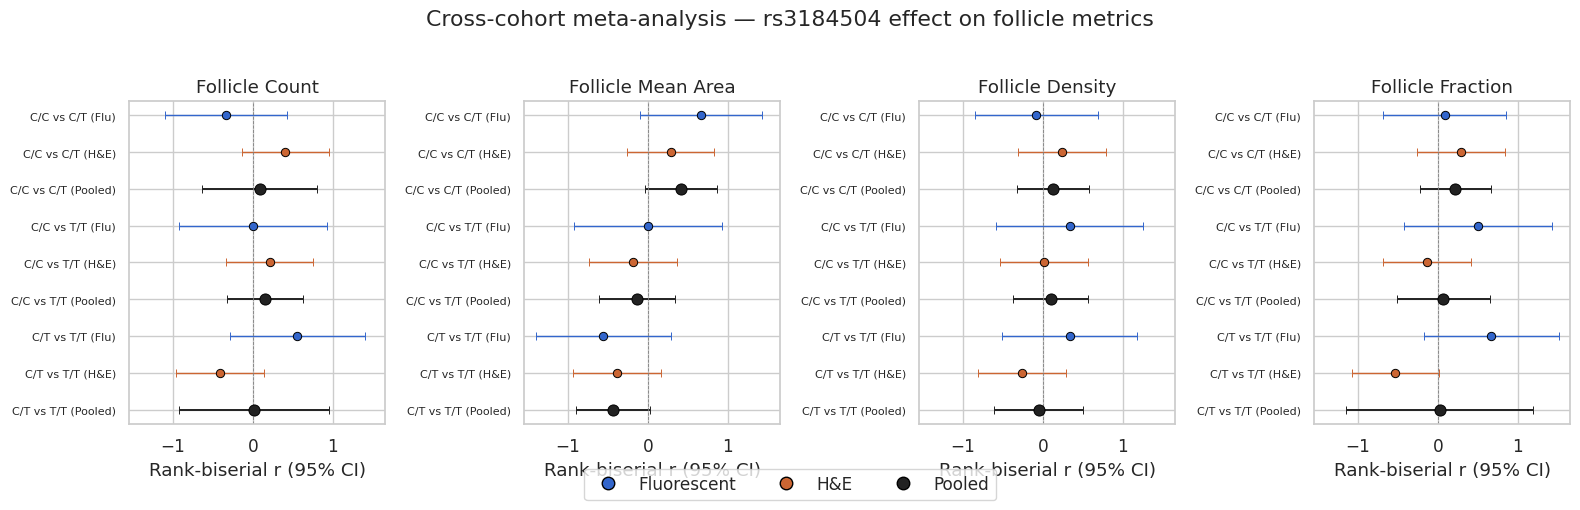

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.8), sharex=True)
for ax, metric in zip(axes, METRICS):
    rows = []
    for test in ["MW C/C vs C/T", "MW C/C vs T/T", "MW C/T vs T/T"]:
        sub = mw[(mw["Metric"] == metric) & (mw["Test"] == test)]
        for _, r in sub.iterrows():
            rows.append((f"{test.replace('MW ','')} ({r['Cohort'][:3]})", r["Effect"],
                         np.sqrt(r["var"]) * 1.96 if pd.notna(r["var"]) else np.nan,
                         r["Cohort"]))
        meta_row = meta_df[(meta_df["Metric"] == metric) & (meta_df["Test"] == test)].squeeze()
        if isinstance(meta_row, pd.Series) and pd.notna(meta_row.get("Pooled_r", np.nan)):
            rows.append((f"{test.replace('MW ','')} (Pooled)",
                         meta_row["Pooled_r"], (meta_row["ci_hi"] - meta_row["ci_lo"]) / 2,
                         "Pooled"))
    if not rows:
        continue
    ypos = np.arange(len(rows))[::-1]
    for y, (label, eff, hw, cohort) in zip(ypos, rows):
        color = COHORT_PALETTE.get(cohort, "grey")
        ax.errorbar(eff, y, xerr=hw, fmt="o", color=color, ecolor=color,
                    capsize=3, markersize=8 if cohort == "Pooled" else 6,
                    markeredgecolor="black", markeredgewidth=0.7,
                    elinewidth=1.4 if cohort == "Pooled" else 1.0)
    ax.axvline(0, color="grey", lw=0.6, ls="--")
    ax.set_yticks(ypos)
    ax.set_yticklabels([r[0] for r in rows], fontsize=8)
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("Rank-biserial r (95% CI)")

handles = [plt.Line2D([0], [0], marker="o", linestyle="None", color=c, markersize=9,
                       markeredgecolor="black", label=k)
           for k, c in COHORT_PALETTE.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Cross-cohort meta-analysis — rs3184504 effect on follicle metrics", y=1.02)
plt.tight_layout()
du.save_figure(fig, "H19_forest_rb")
plt.show()

## 8. Sample-level consistency on overlapping donors

Four donors are in both cohorts (HDL055, HDL063, HDL073, HDL086). Check whether per-donor metrics agree across stains. Small n=4, so this is descriptive.

Saved: analysis/tables/H19_overlap_pairs.csv


Saved: analysis/figures/H19_overlap_consistency.png


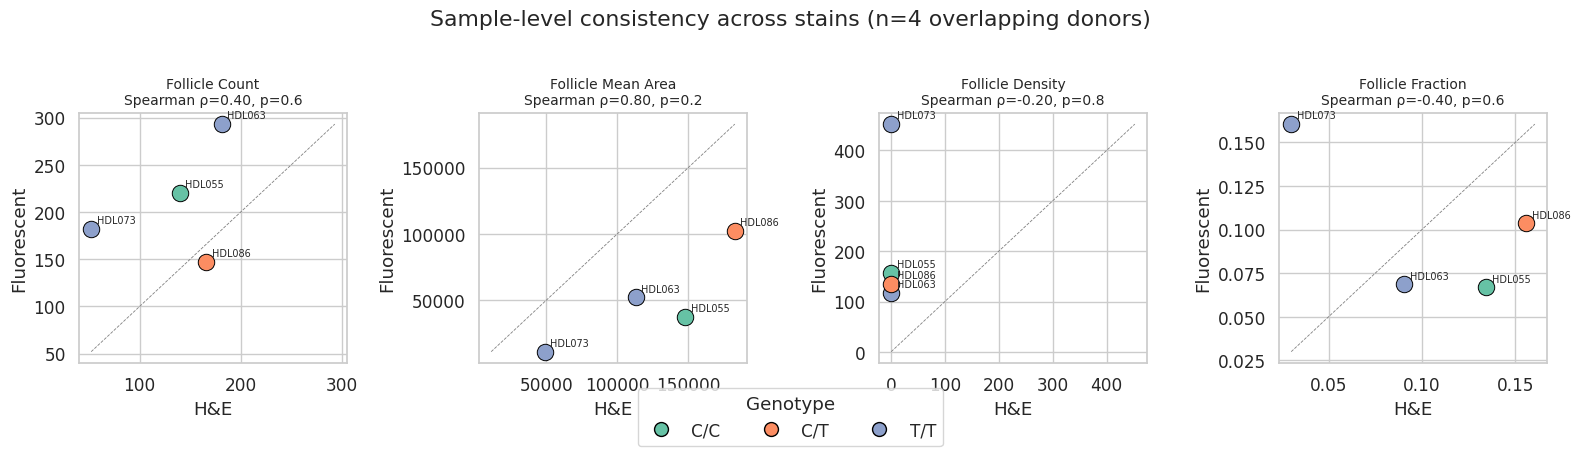

In [10]:
overlap_he = he_unified[he_unified["Sample"].isin(overlap)].set_index("Sample")
overlap_flu = flu_unified[flu_unified["Sample"].isin(overlap)].set_index("Sample")

paired_rows = []
for sample in overlap:
    for metric in METRICS:
        paired_rows.append({"Sample": sample, "Metric": metric,
                            "Genotype": overlap_he.loc[sample, "Genotype"],
                            "HE": overlap_he.loc[sample, metric],
                            "Fluorescent": overlap_flu.loc[sample, metric]})
paired = pd.DataFrame(paired_rows)
du.save_table(paired, "H19_overlap_pairs")

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, metric in zip(axes, METRICS):
    sub = paired[paired["Metric"] == metric]
    for _, r in sub.iterrows():
        ax.scatter(r["HE"], r["Fluorescent"],
                   color=PALETTE[r["Genotype"]], s=140, edgecolor="black", linewidth=0.7)
        ax.annotate(r["Sample"], (r["HE"], r["Fluorescent"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
    if sub[["HE", "Fluorescent"]].notna().all(axis=1).sum() >= 3:
        rho, p = spearmanr(sub["HE"], sub["Fluorescent"])
        ax.set_title(f"{metric.replace('_', ' ')}\nSpearman ρ={rho:.2f}, p={p:.2g}", fontsize=10)
    else:
        ax.set_title(metric.replace("_", " "))
    lo = min(sub["HE"].min(), sub["Fluorescent"].min())
    hi = max(sub["HE"].max(), sub["Fluorescent"].max())
    ax.plot([lo, hi], [lo, hi], color="grey", ls="--", lw=0.6)
    ax.set_xlabel("H&E"); ax.set_ylabel("Fluorescent")

handles = [plt.Line2D([0], [0], marker="o", linestyle="None", color=PALETTE[g],
                       markersize=10, markeredgecolor="black", label=g)
           for g in GENO_ORDER]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04), title="Genotype")
fig.suptitle(f"Sample-level consistency across stains (n={len(overlap)} overlapping donors)", y=1.02)
plt.tight_layout()
du.save_figure(fig, "H19_overlap_consistency")
plt.show()

## 9. Summary

In [11]:
# Pull headline numbers
print("=" * 78)
print("Headline cross-cohort meta-analysis results (rs3184504)")
print("=" * 78)
print()

print("Stouffer-combined dosage trend p-values (smaller = stronger pooled trend):")
for _, r in combined_df.iterrows():
    flag = "  ***" if r["Stouffer_p"] < 0.05 else ("   *" if r["Stouffer_p"] < 0.1 else "    ")
    print(f"  {r['Metric']:<22s}  Z={r['Stouffer_Z']:+.2f}  p={r['Stouffer_p']:.4g}{flag}  "
          f"(Flu rho={r['Fluorescent_rho']:+.2f} n={int(r['Fluorescent_n'])}; "
          f"HE rho={r['HE_rho']:+.2f} n={int(r['HE_n'])})")
print()
print(f"Direction concordance across {len(wide)} (metric, test) pairs: "
      f"{wide['Sign_agree'].mean():.0%} sign agreement.")
print()
print("Random-effects pooled r (largest |effect| at top):")
top = meta_df.dropna(subset=["Pooled_r"]).reindex(meta_df["Pooled_r"].abs().sort_values(ascending=False).index)
for _, r in top.head(8).iterrows():
    flag = "  ***" if r["Pooled_p"] < 0.05 else ("   *" if r["Pooled_p"] < 0.1 else "    ")
    print(f"  {r['Metric']:<22s} {r['Test']:<18s}  pooled r={r['Pooled_r']:+.2f}  "
          f"95%CI [{r['ci_lo']:+.2f}, {r['ci_hi']:+.2f}]  p={r['Pooled_p']:.3g}  I2={r['I2']:.0f}%{flag}")

Headline cross-cohort meta-analysis results (rs3184504)

Stouffer-combined dosage trend p-values (smaller = stronger pooled trend):
  Follicle_Count          Z=+0.43  p=0.6665      (Flu rho=+0.01 n=13; HE rho=+0.10 n=27)
  Follicle_Mean_Area      Z=-0.26  p=0.795      (Flu rho=+0.10 n=13; HE rho=-0.11 n=27)
  Follicle_Density        Z=+0.30  p=0.7625      (Flu rho=+0.16 n=13; HE rho=+0.00 n=27)
  Follicle_Fraction       Z=+0.18  p=0.854      (Flu rho=+0.36 n=13; HE rho=-0.12 n=27)

Direction concordance across 16 (metric, test) pairs: 31% sign agreement.

Random-effects pooled r (largest |effect| at top):
  Follicle_Mean_Area     MW C/T vs T/T       pooled r=-0.43  95%CI [-0.89, +0.03]  p=0.0642  I2=0%   *
  Follicle_Mean_Area     MW C/C vs C/T       pooled r=+0.41  95%CI [-0.03, +0.86]  p=0.069  I2=0%   *
  Follicle_Fraction      MW C/C vs C/T       pooled r=+0.22  95%CI [-0.23, +0.66]  p=0.342  I2=0%    
  Follicle_Count         MW C/C vs T/T       pooled r=+0.16  95%CI [-0.32, +0.63